In [74]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [75]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)

In [76]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [77]:
#CL VS NONCL

In [78]:
##################################
#PLOTTING
all_cloudbase=1.24

In [79]:
types = ["ALL", "SHALLOW", "DEEP"]
variables = ["VMF_c","VMF_g"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"CL_{t}_profile_array_{var}")
        vars_list.append(f"nonCL_{t}_profile_array_{var}")

# Define directory and output file path
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
output_file = dir3+f"CL_nonCL_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list:
        globals()[var] = f[f'{var}'][:]

In [80]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [81]:
var_units = [
    ("VMF_c", "VMF_c (kg/m²/s)"),
    ("VMF_g", "VMF_g (kg/m²/s)"),
]

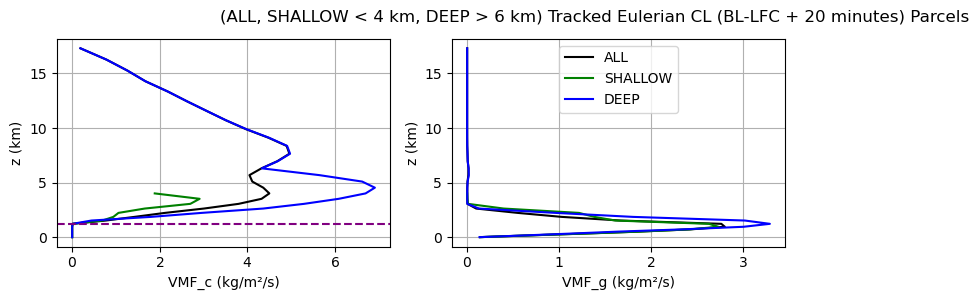

In [82]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = [
    (
        globals()[f"CL_ALL_profile_array_{var}"].copy(),
        globals()[f"CL_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"CL_DEEP_profile_array_{var}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):

    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,color,label) in zip(profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')


    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


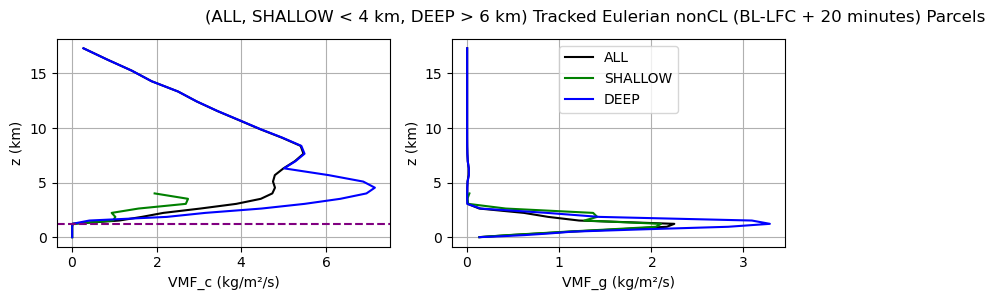

In [83]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"nonCL_ALL_profile_array_{var}"].copy(),
        globals()[f"nonCL_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"nonCL_DEEP_profile_array_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):

    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,color,label) in zip(profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        

        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')


    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# # #FIXING X AXISES TO MATCH PREVIOUS PLOTS
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# fix_x_limits([ax1,ax8])
# fix_x_limits([ax2,ax9])
# fix_x_limits([ax3,ax10])
# fix_x_limits([ax4,ax11])
# fix_x_limits([ax5,ax12])
# fix_x_limits([ax6,ax13])
# fix_x_limits([ax7,ax14])

In [84]:
#DIFFERENCES

def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"CL_{category}_profile_array_{var}"],
            globals()[f"nonCL_{category}_profile_array_{var}"]
        )

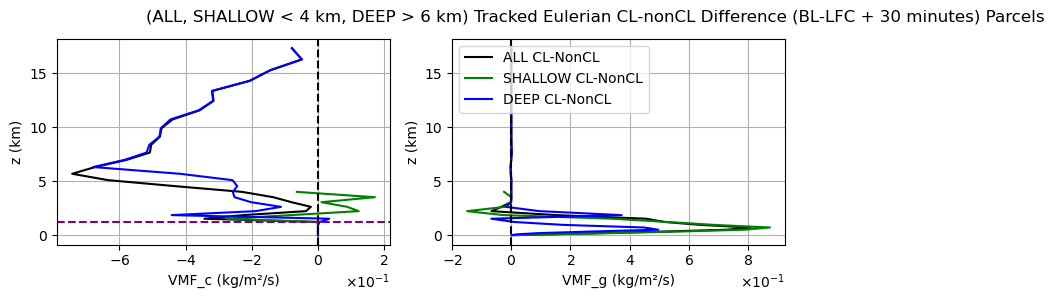

In [85]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')
        
    apply_scientific_notation([ax])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian CL-nonCL Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [86]:
#SBZ vs NONSBZ
################################################################

In [87]:
##################################
#PLOTTING

In [88]:
types = ["ALL", "SHALLOW", "DEEP"]
variables = ["VMF_c","VMF_g"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"SBZ_{t}_profile_array_{var}")
        vars_list.append(f"nonSBZ_{t}_profile_array_{var}")

# Define directory and output file path
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
output_file = dir3+f"SBZ_nonSBZ_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list:
        globals()[var] = f[f'{var}'][:]

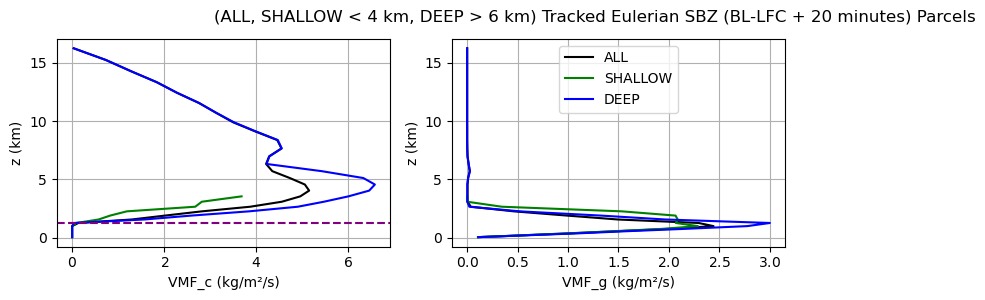

In [89]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = [
    (
        globals()[f"SBZ_ALL_profile_array_{var}"].copy(),
        globals()[f"SBZ_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"SBZ_DEEP_profile_array_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):

    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,color,label) in zip(profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


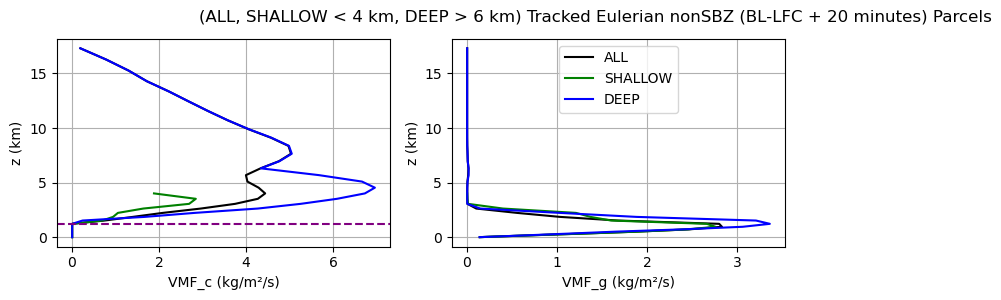

In [90]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"nonSBZ_ALL_profile_array_{var}"].copy(),
        globals()[f"nonSBZ_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"nonSBZ_DEEP_profile_array_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):

    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,color,label) in zip(profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        

        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# # #FIXING X AXISES TO MATCH PREVIOUS PLOTS
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# fix_x_limits([ax1,ax8])
# fix_x_limits([ax2,ax9])
# fix_x_limits([ax3,ax10])
# fix_x_limits([ax4,ax11])
# fix_x_limits([ax5,ax12])
# fix_x_limits([ax6,ax13])
# fix_x_limits([ax7,ax14])

In [91]:
#SBZ vs nonSBZ
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile


var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"SBZ_{category}_profile_array_{var}"],
            globals()[f"nonSBZ_{category}_profile_array_{var}"]
        )

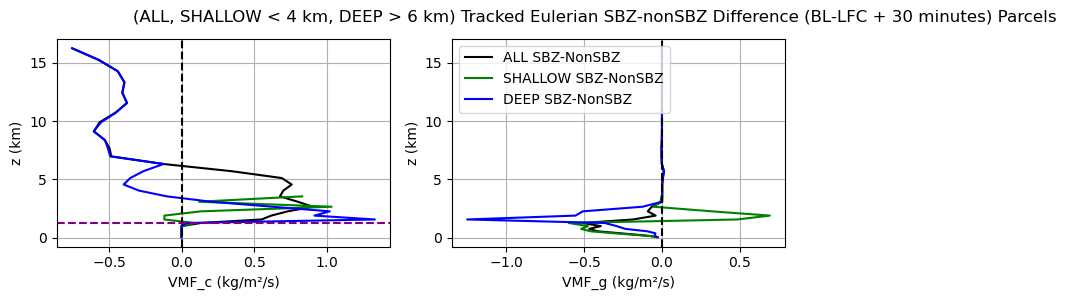

In [92]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-NonSBZ')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-NonSBZ')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-NonSBZ')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')
        
    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1=axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ-nonSBZ Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [69]:
#ColdPool
################################################################

In [22]:
#PLOTTING
############################################################

In [70]:

types = ["ALL", "SHALLOW", "DEEP"]
variables = ["VMF_c","VMF_g"]

vars_list = []

for t in types:
    for var in variables:
        vars_list.append(f"ColdPool_{t}_profile_array_{var}")

# Define directory and output file path
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
output_file = dir3 + f"ColdPool_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list:
        globals()[var] = f[f'{var}'][:]

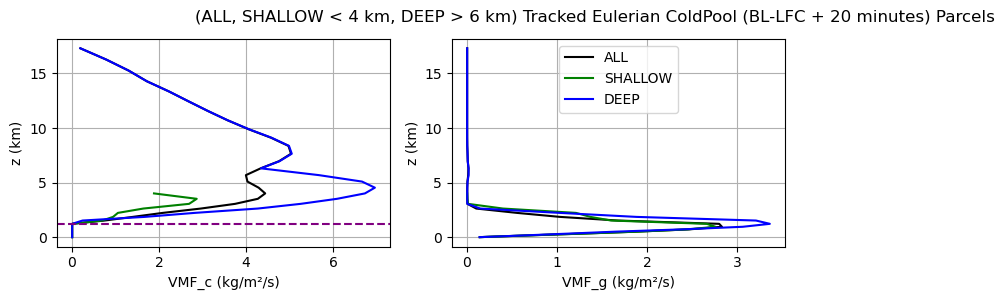

In [71]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (
        globals()[f"ColdPool_ALL_profile_array_{var}"].copy(),
        globals()[f"ColdPool_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"ColdPool_DEEP_profile_array_{var}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):

    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,color,label) in zip(profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1=axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian ColdPool (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [72]:
#SBZ vs ColdPool
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"SBZ_{category}_profile_array_{var}"],
            globals()[f"ColdPool_{category}_profile_array_{var}"]
        )

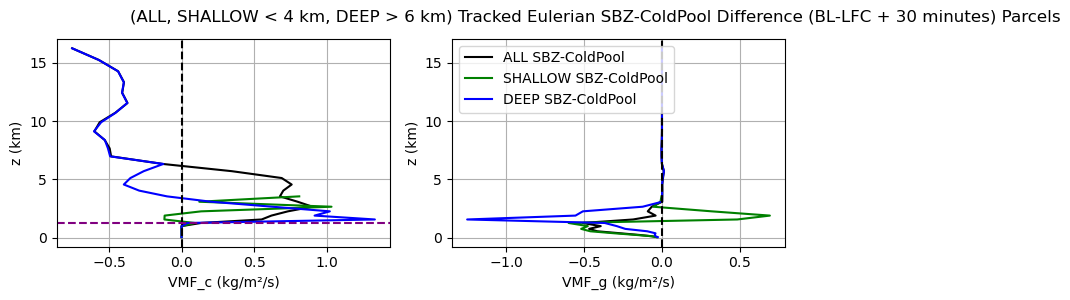

In [73]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]



# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-ColdPool')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-ColdPool')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-ColdPool')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')

    apply_scientific_notation([ax])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ-ColdPool Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()

